## Employee Promotion Eligibility

In [49]:
import numpy as np
import matplotlib.pyplot as plt

In [50]:
# Dataset
X = np.array([
    [1, 5, 2],
    [2, 6, 3],
    [3, 5, 4],
    [2, 4, 2],
    [3, 6, 3],
    [4, 5, 5],
    [5, 7, 6],
    [6, 8, 7],
    [7, 9, 8],
    [5, 8, 6],
    [6, 7, 7],
    [7, 8, 9]
])

y = np.array([
    -1,-1,-1,-1,-1,-1,
     1, 1, 1, 1, 1, 1
])

In [51]:
# Normalize the features
X_scaled = (X-X.mean())/X.std()

In [52]:
w = np.zeros(3)
b = 0
learning_rate = 0.1
epochs = 50 

In [53]:
# Decision Function
def predict(x,w,b):
    z = np.dot(w,x) + b

    if z>=0:
        return 1
    else:
        return -1

In [54]:
# Perceptron algo

for epoch in range(epochs):
    errors = 0
    for i in range(len(X_scaled)):
        pred = predict(X_scaled[i],w,b)

        if pred!= y[i]:
            w[:] += learning_rate*X_scaled[i]*y[i]
            b += learning_rate*y[i]
            errors+=1

        # print(f"Epoch {epoch}, Errors: {errors}")

    if errors==0:
        print("Converged at:",epoch,"epoch")
        break

Converged at: 1 epoch


In [55]:
# Final data
print("Weights: ", w)
print("Bias: ", b)

Weights:  [0.18647907 0.09323953 0.18647907]
Bias:  0.0


In [56]:
# Accuracy of the model
correct = 0

for i in range(len(X_scaled)):
    pred = predict(X_scaled[i],w,b)

    if pred==y[i]:
        correct+=1

print("Accuracy of the model: ",correct/len(X))

Accuracy of the model:  1.0


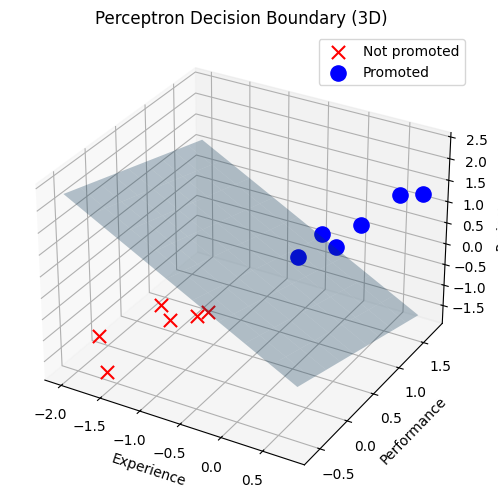

In [57]:
# 3 features - Plane

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

for i in range(len(X_scaled)):
    if y[i]==-1:
        ax.scatter(X_scaled[i,0],X_scaled[i,1],X_scaled[i,2],color='red',marker='x', label='Not promoted' if i==0 else "",s=90)
    else:
        ax.scatter(X_scaled[i,0],X_scaled[i,1],X_scaled[i,2],color='blue',marker='o', label='Promoted' if i==6 else "",s=120)

x1 = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 10)
x2 = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 10)

x1,x2 = np.meshgrid(x1,x2)

# Solve x3 to compute height of z-axis
if (abs(w[2]))> 1e-6:
    x3 = -(w[0]*x1+w[1]*x2+b)/w[2]
    ax.plot_surface(x1,x2,x3,alpha=0.3,shade=True)


ax.set_xlabel("Experience")
ax.set_ylabel("Performance")
ax.set_zlabel("Projects")

plt.title("Perceptron Decision Boundary (3D)")
plt.legend()
plt.show()